# Task 1

In [ ]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
!unzip /content/kmeans_data.zip
!rm -rf /content/__MACOSX

Archive:  /content/kmeans_data.zip
  inflating: data_description.txt    
  inflating: data.csv                
  inflating: __MACOSX/._data.csv     
  inflating: label.csv               
  inflating: __MACOSX/._label.csv    


In [ ]:
X = pd.read_csv('data.csv', header=None).values.astype(float)
y = pd.read_csv('label.csv', header=None).values.flatten()
K = len(np.unique(y))

In [ ]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def cosine_distance(a, b):
    dot = np.dot(a, b)
    norm_a = np.sqrt(np.sum(a ** 2))
    norm_b = np.sqrt(np.sum(b ** 2))
    if norm_a == 0 or norm_b == 0:
        return 1.0
    return 1 - (dot / (norm_a * norm_b))

def jaccard_distance(a, b):
    numerator   = np.sum(np.minimum(a, b))
    denominator = np.sum(np.maximum(a, b))
    if denominator == 0:
        return 0.0
    return 1 - (numerator / denominator)

In [ ]:
def calculate_sse(X, labels, centroids):
    total_sse = 0.0
    for i in range(len(X)):
        total_sse += np.sum((X[i] - centroids[labels[i]]) ** 2)
    return total_sse

In [ ]:
def run_kmeans(X, K, distance_func, max_iterations=500, random_state=42):
    np.random.seed(random_state)
    num_points = X.shape[0]
    random_indices = np.random.choice(num_points, K, replace=False)
    centroids = X[random_indices].copy().astype(float)

    cluster_labels = np.zeros(num_points, dtype=int)
    sse_history = []
    stop_reason = "max iterations reached"

    for iteration in range(max_iterations):
        new_cluster_labels = np.zeros(num_points, dtype=int)
        for i in range(num_points):
            distances = []
            for k in range(K):
                dist = distance_func(X[i], centroids[k])
                distances.append(dist)
            new_cluster_labels[i] = np.argmin(distances)

        current_sse = calculate_sse(X, new_cluster_labels, centroids)
        sse_history.append(current_sse)

        if iteration > 0 and current_sse > sse_history[-2]:
            cluster_labels = new_cluster_labels
            stop_reason = "SSE increased at iteration " + str(iteration + 1)
            break

        if iteration > 0 and np.array_equal(new_cluster_labels, cluster_labels):
            cluster_labels = new_cluster_labels
            stop_reason = "no change at iteration " + str(iteration + 1)
            break

        cluster_labels = new_cluster_labels
        for k in range(K):
            points_in_cluster = X[cluster_labels == k]
            if len(points_in_cluster) > 0:
                centroids[k] = np.mean(points_in_cluster, axis=0)

    final_sse = sse_history[-1]
    total_iterations = len(sse_history)

    return cluster_labels, centroids, final_sse, sse_history, total_iterations, stop_reason

In [ ]:
def compute_accuracy(true_labels, predicted_labels, K):
    cluster_to_label = {}
    for k in range(K):
        pts = true_labels[predicted_labels == k]
        if len(pts) == 0:
            cluster_to_label[k] = -1
        else:
            cluster_to_label[k] = Counter(pts).most_common(1)[0][0]

    mapped = np.array([cluster_to_label[p] for p in predicted_labels])
    accuracy = np.sum(mapped == true_labels) / len(true_labels)
    return accuracy

X shape : (9999, 784)
y shape : (9999,)
Unique labels (K) : [0 1 2 3 4 5 6 7 8 9]
Number of clusters K = 10


In [ ]:
def compute_all_distances(X, centroids, distance_func):
    num_points = X.shape[0]
    K = len(centroids)
    dist_matrix = np.zeros((num_points, K))
    for k in range(K):
        for i in range(num_points):
            dist_matrix[i, k] = distance_func(X[i], centroids[k])

    return dist_matrix

In [ ]:
def run_kmeans(X, K, distance_func, max_iterations=500, random_state=42):
    np.random.seed(random_state)
    num_points = X.shape[0]
    random_indices = np.random.choice(num_points, K, replace=False)
    centroids = X[random_indices].copy().astype(float)
    cluster_labels = np.zeros(num_points, dtype=int)
    sse_history = []

    for iteration in range(max_iterations):
        new_cluster_labels = np.zeros(num_points, dtype=int)
        for i in range(num_points):
            distances = []
            for k in range(K):
                dist = distance_func(X[i], centroids[k])
                distances.append(dist)
            new_cluster_labels[i] = np.argmin(distances)

        current_sse = calculate_sse(X, new_cluster_labels, centroids)
        sse_history.append(current_sse)

        if iteration > 0 and current_sse > sse_history[-2]:
            cluster_labels = new_cluster_labels
            break

        if iteration > 0 and np.array_equal(new_cluster_labels, cluster_labels):
            cluster_labels = new_cluster_labels
            break

        cluster_labels = new_cluster_labels
        for k in range(K):
            points_in_cluster = X[cluster_labels == k]
            if len(points_in_cluster) > 0:
                centroids[k] = np.mean(points_in_cluster, axis=0)

    return cluster_labels, centroids, sse_history[-1]

## Q1

In [ ]:
euclidean_labels, euclidean_centroids, euclidean_sse = run_kmeans(X, K, euclidean_distance)
cosine_labels, cosine_centroids, cosine_sse = run_kmeans(X, K, cosine_distance)
jaccard_labels, jaccard_centroids, jaccard_sse = run_kmeans(X, K, jaccard_distance)

In [ ]:
print(f"Euclidean SSE : {euclidean_sse:.4f}")
print(f"Cosine SSE : {cosine_sse:.4f}")
print(f"Jaccard SSE : {jaccard_sse:.4f}")

Euclidean SSE : 25414767689.9611
Cosine SSE    : 25489044045.3560
Jaccard SSE   : 25415242340.2997


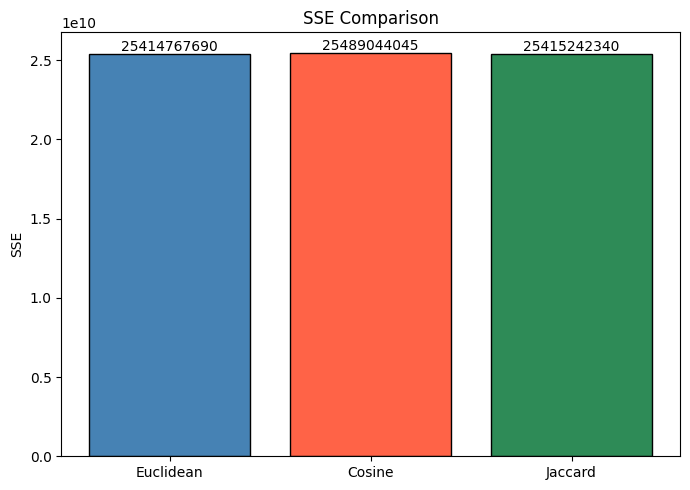

In [ ]:
method_names = ['Euclidean', 'Cosine', 'Jaccard']
sse_values   = [euclidean_sse, cosine_sse, jaccard_sse]
bar_colors   = ['steelblue', 'tomato', 'seagreen']

plt.figure(figsize=(7, 5))
bars = plt.bar(method_names, sse_values, color=bar_colors, edgecolor='black')
plt.title("SSE Comparison")
plt.ylabel("SSE")
for bar, val in zip(bars, sse_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{val:.0f}", ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('q1_sse_comparison.png', dpi=150)
plt.show()

## Q2

In [ ]:
def compute_accuracy(true_labels, cluster_labels, K):
    cluster_to_true_label = {}
    for k in range(K):
        true_labels_in_cluster = true_labels[cluster_labels == k]

        if len(true_labels_in_cluster) == 0:
            cluster_to_true_label[k] = -1
        else:
            majority_label = Counter(true_labels_in_cluster).most_common(1)[0][0]
            cluster_to_true_label[k] = majority_label

    predicted_labels = np.array([cluster_to_true_label[c] for c in cluster_labels])
    accuracy = np.sum(predicted_labels == true_labels) / len(true_labels)
    return accuracy

In [ ]:
euclidean_accuracy = compute_accuracy(y, euclidean_labels, K)
cosine_accuracy = compute_accuracy(y, cosine_labels, K)
jaccard_accuracy = compute_accuracy(y, jaccard_labels, K)

In [ ]:
print(f"Euclidean Accuracy : {euclidean_accuracy:.4f}")
print(f"Cosine Accuracy : {cosine_accuracy:.4f}")
print(f"Jaccard Accuracy : {jaccard_accuracy:.4f}")

Euclidean Accuracy : 0.5851
Cosine Accuracy : 0.6305
Jaccard Accuracy : 0.6029


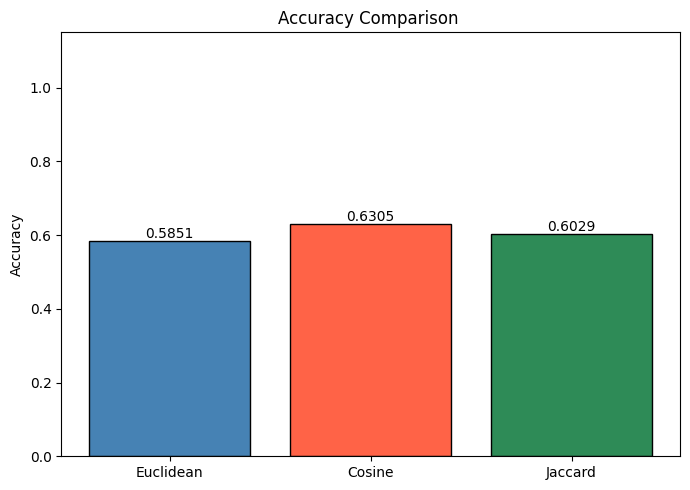

In [ ]:
accuracy_values = [euclidean_accuracy, cosine_accuracy, jaccard_accuracy]
plt.figure(figsize=(7, 5))
bars = plt.bar(method_names, accuracy_values, color=bar_colors, edgecolor='black')
plt.title("Accuracy Comparison ")
plt.ylabel("Accuracy")
plt.ylim(0, 1.15)
for bar, val in zip(bars, accuracy_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{val:.4f}", ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('q2_accuracy_comparison.png', dpi=150)
plt.show()

## Q3

In [ ]:
def run_kmeans_tracked(X, K, distance_func, max_iterations=500, random_state=42):
    np.random.seed(random_state)
    num_points = X.shape[0]
    random_indices = np.random.choice(num_points, K, replace=False)
    centroids      = X[random_indices].copy().astype(float)
    cluster_labels = np.zeros(num_points, dtype=int)
    sse_history    = []

    for iteration in range(max_iterations):

        new_cluster_labels = np.zeros(num_points, dtype=int)
        for i in range(num_points):
            distances = []
            for k in range(K):
                dist = distance_func(X[i], centroids[k])
                distances.append(dist)
            new_cluster_labels[i] = np.argmin(distances)

        current_sse = calculate_sse(X, new_cluster_labels, centroids)
        sse_history.append(current_sse)

        if iteration > 0 and current_sse > sse_history[-2]:
            cluster_labels = new_cluster_labels
            break

        if iteration > 0 and np.array_equal(new_cluster_labels, cluster_labels):
            cluster_labels = new_cluster_labels
            break

        cluster_labels = new_cluster_labels

        for k in range(K):
            points_in_cluster = X[cluster_labels == k]
            if len(points_in_cluster) > 0:
                centroids[k] = np.mean(points_in_cluster, axis=0)

    total_iterations = len(sse_history)
    return cluster_labels, total_iterations

In [ ]:
start_time = time.time()
_, euclidean_iters = run_kmeans_tracked(X, K, euclidean_distance)
euclidean_time = time.time() - start_time

start_time = time.time()
_, cosine_iters = run_kmeans_tracked(X, K, cosine_distance)
cosine_time = time.time() - start_time

start_time = time.time()
_, jaccard_iters = run_kmeans_tracked(X, K, jaccard_distance)
jaccard_time = time.time() - start_time

In [ ]:
print(f"Euclidean Iterations: {euclidean_iters},  Time: {euclidean_time:.2f}s")
print(f"Cosine Iterations: {cosine_iters},  Time: {cosine_time:.2f}s")
print(f"Jaccard Iterations: {jaccard_iters},  Time: {jaccard_time:.2f}s")

Euclidean Iterations: 33,  Time: 47.16s
Cosine Iterations: 34,  Time: 74.41s
Jaccard Iterations: 38,  Time: 61.86s


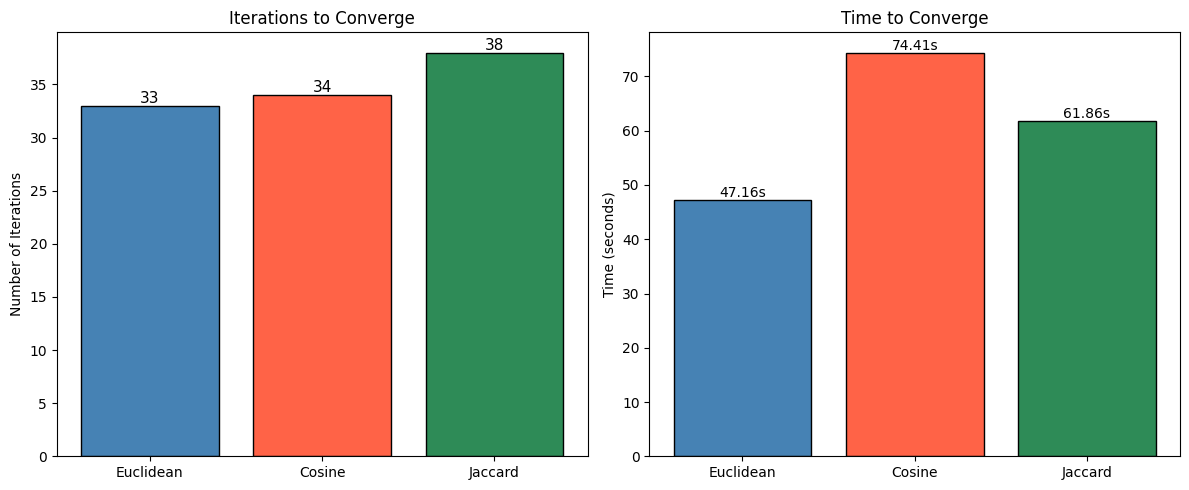

In [ ]:
iteration_values = [euclidean_iters, cosine_iters, jaccard_iters]
time_values = [euclidean_time,  cosine_time,  jaccard_time]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars1 = axes[0].bar(method_names, iteration_values, color=bar_colors, edgecolor='black')
axes[0].set_title("Iterations to Converge")
axes[0].set_ylabel("Number of Iterations")
for bar, val in zip(bars1, iteration_values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 str(val), ha='center', va='bottom', fontsize=11)

bars2 = axes[1].bar(method_names, time_values, color=bar_colors, edgecolor='black')
axes[1].set_title("Time to Converge")
axes[1].set_ylabel("Time (seconds)")
for bar, val in zip(bars2, time_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f"{val:.2f}s", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('q3_iterations_time.png', dpi=150)
plt.show()

## Q4

In [ ]:
def run_kmeans_with_stop(X, K, distance_func, stop_mode, max_iterations=100, random_state=42):
    np.random.seed(random_state)
    num_points = X.shape[0]
    random_indices = np.random.choice(num_points, K, replace=False)
    centroids = X[random_indices].copy().astype(float)
    cluster_labels = np.zeros(num_points, dtype=int)
    sse_history = []

    for iteration in range(max_iterations):
        new_cluster_labels = np.zeros(num_points, dtype=int)
        for i in range(num_points):
            distances = []
            for k in range(K):
                dist = distance_func(X[i], centroids[k])
                distances.append(dist)
            new_cluster_labels[i] = np.argmin(distances)

        current_sse = calculate_sse(X, new_cluster_labels, centroids)
        sse_history.append(current_sse)

        if stop_mode == 'sse_increase' and iteration > 0:
            if current_sse > sse_history[-2]:
                break

        if stop_mode == 'no_change' and iteration > 0:
            if np.array_equal(new_cluster_labels, cluster_labels):
                break

        cluster_labels = new_cluster_labels

        for k in range(K):
            points_in_cluster = X[cluster_labels == k]
            if len(points_in_cluster) > 0:
                centroids[k] = np.mean(points_in_cluster, axis=0)

    return sse_history[-1]

In [ ]:
euclidean_sse_nochange = run_kmeans_with_stop(X, K, euclidean_distance, stop_mode='no_change')
euclidean_sse_sseincrease = run_kmeans_with_stop(X, K, euclidean_distance, stop_mode='sse_increase')
euclidean_sse_maxiter = run_kmeans_with_stop(X, K, euclidean_distance, stop_mode='max_iter')

cosine_sse_nochange = run_kmeans_with_stop(X, K, cosine_distance, stop_mode='no_change')
cosine_sse_sseincrease = run_kmeans_with_stop(X, K, cosine_distance, stop_mode='sse_increase')
cosine_sse_maxiter = run_kmeans_with_stop(X, K, cosine_distance, stop_mode='max_iter')

jaccard_sse_nochange = run_kmeans_with_stop(X, K, jaccard_distance, stop_mode='no_change')
jaccard_sse_sseincrease = run_kmeans_with_stop(X, K, jaccard_distance, stop_mode='sse_increase')
jaccard_sse_maxiter = run_kmeans_with_stop(X, K, jaccard_distance, stop_mode='max_iter')

In [ ]:
print("Q4 — SSE by Stopping Condition\n")
print(f"Euclidean  |  No Change: {euclidean_sse_nochange:.4f}  |  SSE Increases: {euclidean_sse_sseincrease:.4f}  |  Max Iter (100): {euclidean_sse_maxiter:.4f}")
print(f"Cosine     |  No Change: {cosine_sse_nochange:.4f}  |  SSE Increases: {cosine_sse_sseincrease:.4f}  |  Max Iter (100): {cosine_sse_maxiter:.4f}")
print(f"Jaccard    |  No Change: {jaccard_sse_nochange:.4f}  |  SSE Increases: {jaccard_sse_sseincrease:.4f}  |  Max Iter (100): {jaccard_sse_maxiter:.4f}")

Q4 — SSE by Stopping Condition

Method            No Change   SSE Increases   Max Iter (100)
------------------------------------------------------------
Euclidean    25414767689.9611 25414767689.9611 25414767689.9611
Cosine       25489564392.2771 25489044045.3560 25489564392.2771
Jaccard      25416346592.3901 25415242340.2997 25416346592.3901


# Task 2

In [ ]:
!pip install numpy==1.26.4 scikit-surprise -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 35.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible

In [ ]:
from surprise import Dataset, Reader, SVD, KNNBasic
from surprise.model_selection import cross_validate

In [ ]:
ratings = pd.read_csv('ratings_small.csv')
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

## Q2c

In [ ]:
pmf_model = SVD()
user_cf_model = KNNBasic(sim_options={'name': 'cosine', 'user_based': True})
item_cf_model = KNNBasic(sim_options={'name': 'cosine', 'user_based': False})

In [ ]:
pmf_results = cross_validate(pmf_model, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)
user_cf_results = cross_validate(user_cf_model, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)
item_cf_results = cross_validate(item_cf_model, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.


In [ ]:
pmf_rmse = np.mean(pmf_results['test_rmse'])
pmf_mae = np.mean(pmf_results['test_mae'])

In [ ]:
user_cf_rmse = np.mean(user_cf_results['test_rmse'])
user_cf_mae = np.mean(user_cf_results['test_mae'])

In [ ]:
item_cf_rmse = np.mean(item_cf_results['test_rmse'])
item_cf_mae  = np.mean(item_cf_results['test_mae'])

In [ ]:
print(f"PMF => RMSE: {pmf_rmse:.4f} ; MAE: {pmf_mae:.4f}")
print(f"User-based CF => RMSE: {user_cf_rmse:.4f} ; MAE: {user_cf_mae:.4f}")
print(f"Item-based CF => RMSE: {item_cf_rmse:.4f} ; MAE: {item_cf_mae:.4f}")

PMF => RMSE: 0.8971 ; MAE: 0.6909
User-based CF => RMSE: 0.9935 ; MAE: 0.7680
Item-based CF => RMSE: 0.9951 ; MAE: 0.7747


## Q2d

In [ ]:
model_names = ['PMF', 'User-based CF', 'Item-based CF']
rmse_values = [pmf_rmse, user_cf_rmse, item_cf_rmse]
mae_values  = [pmf_mae,  user_cf_mae,  item_cf_mae]

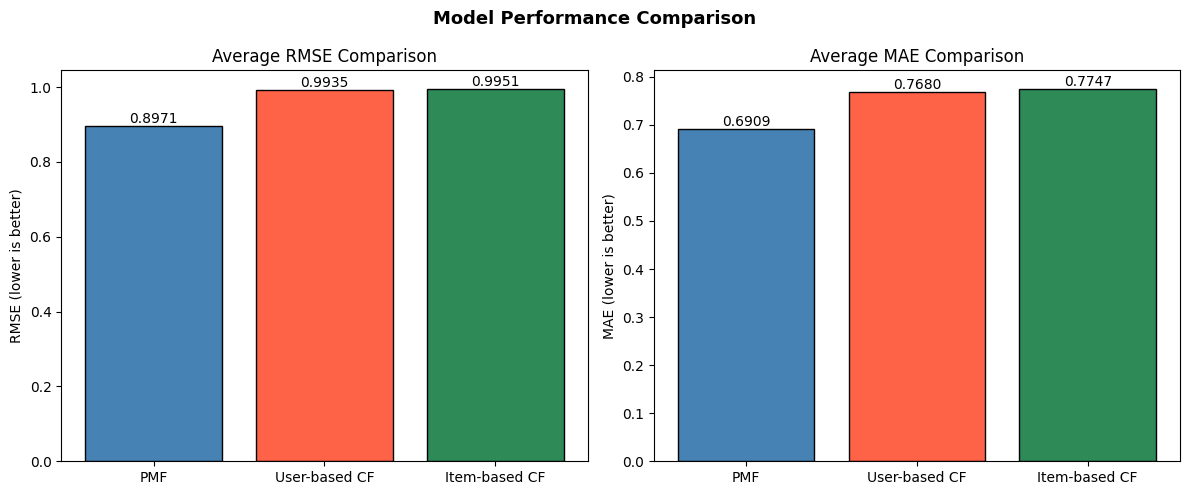

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RMSE comparison
bars1 = axes[0].bar(model_names, rmse_values, color=['steelblue', 'tomato', 'seagreen'], edgecolor='black')
axes[0].set_title("Average RMSE Comparison")
axes[0].set_ylabel("RMSE (lower is better)")
for bar, val in zip(bars1, rmse_values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f"{val:.4f}", ha='center', va='bottom', fontsize=10)

# MAE comparison
bars2 = axes[1].bar(model_names, mae_values, color=['steelblue', 'tomato', 'seagreen'], edgecolor='black')
axes[1].set_title("Average MAE Comparison")
axes[1].set_ylabel("MAE (lower is better)")
for bar, val in zip(bars2, mae_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f"{val:.4f}", ha='center', va='bottom', fontsize=10)

plt.suptitle("Model Performance Comparison", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q2d_model_comparison.png', dpi=150)
plt.show()

In [ ]:
similarity_metrics = ['cosine', 'msd', 'pearson']

user_rmse_values = []
user_mae_values  = []
item_rmse_values = []
item_mae_values  = []

for sim in similarity_metrics:
    user_model = KNNBasic(sim_options={'name': sim, 'user_based': True})
    user_results = cross_validate(user_model, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)
    user_rmse_values.append(np.mean(user_results['test_rmse']))
    user_mae_values.append(np.mean(user_results['test_mae']))

    item_model = KNNBasic(sim_options={'name': sim, 'user_based': False})
    item_results = cross_validate(item_model, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)
    item_rmse_values.append(np.mean(item_results['test_rmse']))
    item_mae_values.append(np.mean(item_results['test_mae']))

for i, sim in enumerate(similarity_metrics):
    print(f"{sim:<10} | User RMSE: {user_rmse_values[i]:.4f}  User MAE: {user_mae_values[i]:.4f}  |  Item RMSE: {item_rmse_values[i]:.4f}  Item MAE: {item_mae_values[i]:.4f}")

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd sim

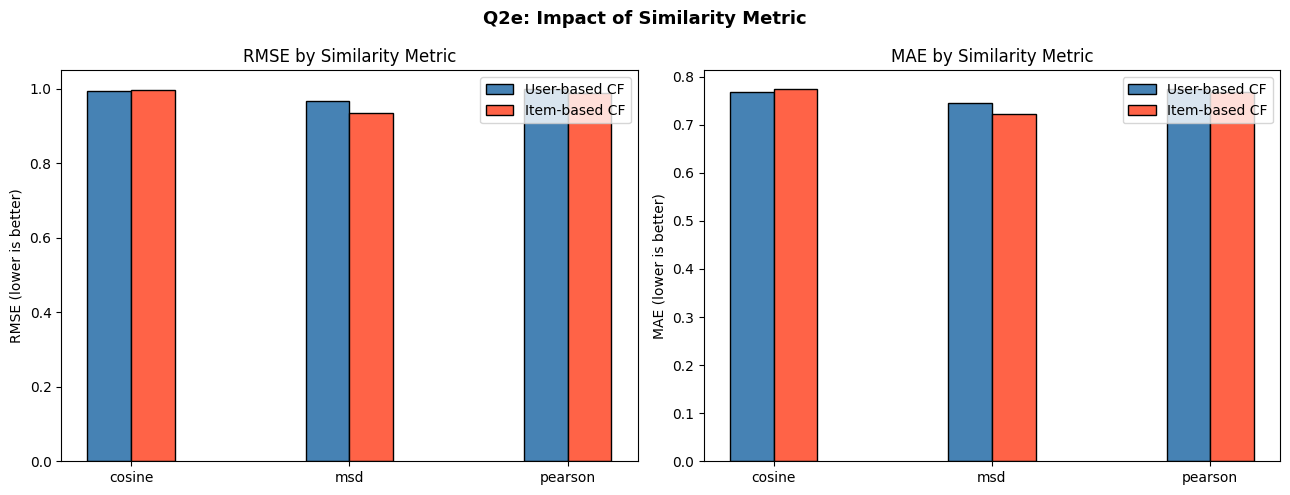

In [ ]:
x_positions = np.arange(len(similarity_metrics))
bar_width    = 0.2
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# RMSE plot
axes[0].bar(x_positions - bar_width / 2, user_rmse_values, bar_width, label='User-based CF', color='steelblue', edgecolor='black')
axes[0].bar(x_positions + bar_width / 2, item_rmse_values, bar_width, label='Item-based CF', color='tomato',    edgecolor='black')
axes[0].set_title("RMSE by Similarity Metric")
axes[0].set_ylabel("RMSE (lower is better)")
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(similarity_metrics)
axes[0].legend()

# MAE plot
axes[1].bar(x_positions - bar_width / 2, user_mae_values, bar_width, label='User-based CF', color='steelblue', edgecolor='black')
axes[1].bar(x_positions + bar_width / 2, item_mae_values, bar_width, label='Item-based CF', color='tomato',    edgecolor='black')
axes[1].set_title("MAE by Similarity Metric")
axes[1].set_ylabel("MAE (lower is better)")
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(similarity_metrics)
axes[1].legend()

plt.suptitle("Impact of Similarity Metric", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q2e_similarity_impact.png', dpi=150)
plt.show()

In [ ]:
neighbor_counts  = [5, 10, 20, 30, 40, 50]
user_rmse_by_k = []
item_rmse_by_k = []
user_mae_by_k  = []
item_mae_by_k  = []

for k in neighbor_counts:
    user_model = KNNBasic(k=k, sim_options={'name': 'cosine', 'user_based': True})
    user_results = cross_validate(user_model, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)
    user_rmse_by_k.append(np.mean(user_results['test_rmse']))
    user_mae_by_k.append(np.mean(user_results['test_mae']))

    item_model = KNNBasic(k=k, sim_options={'name': 'cosine', 'user_based': False})
    item_results = cross_validate(item_model, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)
    item_rmse_by_k.append(np.mean(item_results['test_rmse']))
    item_mae_by_k.append(np.mean(item_results['test_mae']))

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing th

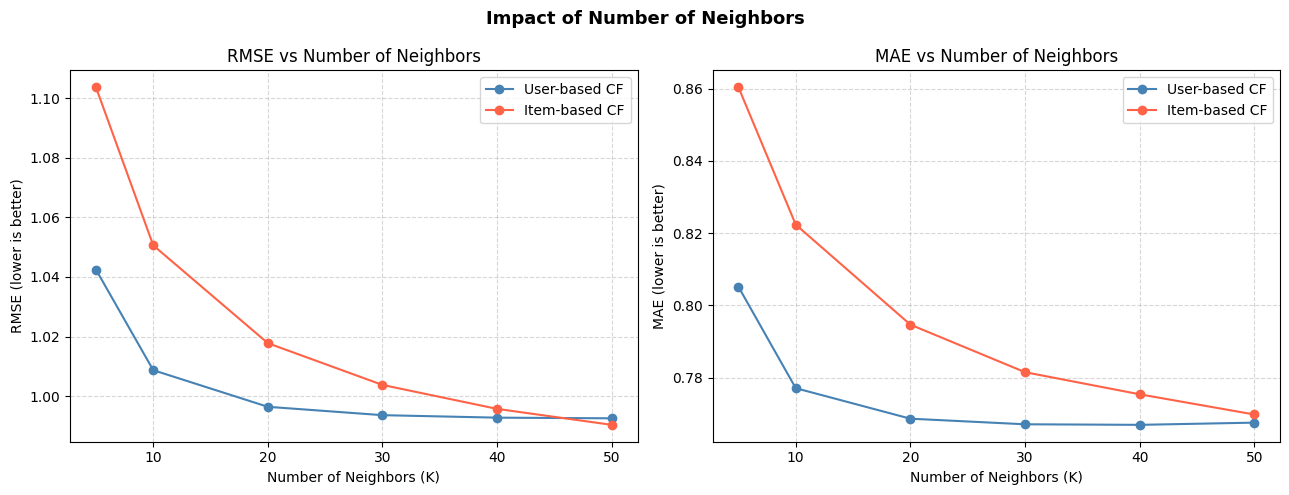

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(neighbor_counts, user_rmse_by_k, marker='o', color='steelblue', label='User-based CF')
axes[0].plot(neighbor_counts, item_rmse_by_k, marker='o', color='tomato',    label='Item-based CF')
axes[0].set_title("RMSE vs Number of Neighbors")
axes[0].set_xlabel("Number of Neighbors (K)")
axes[0].set_ylabel("RMSE (lower is better)")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(neighbor_counts, user_mae_by_k, marker='o', color='steelblue', label='User-based CF')
axes[1].plot(neighbor_counts, item_mae_by_k, marker='o', color='tomato',    label='Item-based CF')
axes[1].set_title("MAE vs Number of Neighbors")
axes[1].set_xlabel("Number of Neighbors (K)")
axes[1].set_ylabel("MAE (lower is better)")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Impact of Number of Neighbors", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q2f_neighbors_impact.png', dpi=150)
plt.show()

In [ ]:
best_user_k_index = np.argmin(user_rmse_by_k)
best_item_k_index = np.argmin(item_rmse_by_k)

best_user_k = neighbor_counts[best_user_k_index]
best_item_k = neighbor_counts[best_item_k_index]

best_user_rmse = user_rmse_by_k[best_user_k_index]
best_item_rmse = item_rmse_by_k[best_item_k_index]

print(f"Best K for User-based CF : K = {best_user_k}  (RMSE: {best_user_rmse:.4f})")
print(f"Best K for Item-based CF : K = {best_item_k}  (RMSE: {best_item_rmse:.4f})")

if best_user_k == best_item_k:
    print(f"\nThe best K is the same for both User-based and Item-based CF (K = {best_user_k})")
else:
    print(f"\nThe best K is different — User-based CF: K = {best_user_k}, Item-based CF: K = {best_item_k}")

Best K for User-based CF : K = 50  (RMSE: 0.9925)
Best K for Item-based CF : K = 50  (RMSE: 0.9903)

The best K is the same for both User-based and Item-based CF (K = 50)
